# 8. XGBoost Tuning and Threshold Optimization

## Objective

The previous experiments showed that XGBoost provides the strongest
overall predictive performance among the evaluated models.

This notebook focuses on:

- Tuning the most important XGBoost hyperparameters.
- Evaluating the tuned model on the validation set.
- Optimizing the classification threshold to improve the balance between
  precision and recall.

Hyperparameter tuning is performed using only the training data.

The validation set is used for model and threshold selection.

The test set remains untouched until the final evaluation.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(
    0,
    str(PROJECT_ROOT)
)


from src.modeling_utils import (
    load_data,
    split_data,
    build_preprocessor,
    evaluate_model
)

print("Project root:", PROJECT_ROOT)

Project root: d:\1-PERSONAL\HOC-TAP\DS\credit-risk-default-prediction


## 1. Data Preparation

The same data preparation and stratified train-validation-test split used
in previous experiments are reused to ensure consistency.

The test set remains isolated from model tuning.

In [2]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "credit_default_features.csv"
)

X, y = load_data(DATA_PATH)

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = split_data(X, y)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (21000, 36)
Validation: (4500, 36)
Test: (4500, 36)


In [3]:
tree_preprocessor = build_preprocessor(
    X,
    scale_numeric=False
)

## 2. XGBoost Hyperparameter Tuning

Randomized Search is used to explore several important XGBoost
hyperparameters without exhaustively testing every possible combination.

Average Precision is used as the optimization metric because the target
class is imbalanced and identifying default customers is particularly
important.

In [4]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count
    / positive_count
)

print(
    "scale_pos_weight:",
    round(scale_pos_weight, 4)
)

scale_pos_weight: 3.521


In [5]:
xgb_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                eval_metric="logloss",
                random_state=42,
                n_jobs=1,
                scale_pos_weight=scale_pos_weight
            )
        )
    ]
)


In [6]:
param_distributions = {
    "classifier__n_estimators": [
        200,
        300,
        500
    ],

    "classifier__max_depth": [
        3,
        4,
        5,
        6
    ],

    "classifier__learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        1.0
    ]
}

In [7]:
random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [8]:
random_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoo

In [9]:
print(
    "Best CV score:",
    round(random_search.best_score_, 4)
)

print(
    "\nBest parameters:"
)

random_search.best_params_

Best CV score: 0.5626

Best parameters:


{'classifier__subsample': 0.8,
 'classifier__n_estimators': 200,
 'classifier__max_depth': 4,
 'classifier__learning_rate': 0.03,
 'classifier__colsample_bytree': 1.0}

In [10]:
best_xgb = random_search.best_estimator_

In [11]:
tuned_results = evaluate_model(
    best_xgb,
    X_val,
    y_val,
    "Tuned XGBoost"
)

tuned_results

{'Model': 'Tuned XGBoost',
 'Accuracy': 0.7551111111111111,
 'Precision': 0.46097738876732314,
 'Recall': 0.6351758793969849,
 'F1': 0.5342349957734573,
 'ROC_AUC': 0.7826436031799511,
 'PR_AUC': 0.561042234485753}

## 3. Classification Threshold Optimization

Binary classifiers use a default probability threshold of 0.50 to convert
predicted probabilities into class predictions.

However, the default threshold may not provide the best balance between
precision and recall for credit default detection.

Several thresholds are evaluated using the validation dataset.

The threshold with the highest F1-score is selected for the final model.

In [12]:
y_val_prob = best_xgb.predict_proba(
    X_val
)[:, 1]

In [14]:
thresholds = np.arange(
    0.20,
    0.71,
    0.05
)

In [15]:
threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_val,
            y_pred_threshold
        ),

        "Precision": precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),

        "F1": f1_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.3807,0.2588,0.9658,0.4082
1,0.25,0.4558,0.2804,0.9327,0.4311
2,0.30,0.5273,0.3043,0.8844,0.4528
3,0.35,0.5998,0.3360,0.8302,0.4784
4,0.40,0.6680,0.3743,0.7467,0.4987
5,0.45,0.7160,0.4131,0.6764,0.5130
6,0.50,0.7551,0.4610,0.6352,0.5342
7,0.55,0.7844,0.5109,0.5910,0.5480
8,0.60,0.7996,0.5475,0.5387,0.5431
9,0.65,0.8104,0.5883,0.4754,0.5258


In [16]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.550000
Accuracy     0.784444
Precision    0.510860
Recall       0.590955
F1           0.547996
Name: 7, dtype: float64

In [17]:
best_threshold = (
    best_threshold_row["Threshold"]
)

print(
    "Selected threshold:",
    round(best_threshold, 2)
)

Selected threshold: 0.55


In [18]:
y_val_final_pred = (
    y_val_prob >= best_threshold
).astype(int)

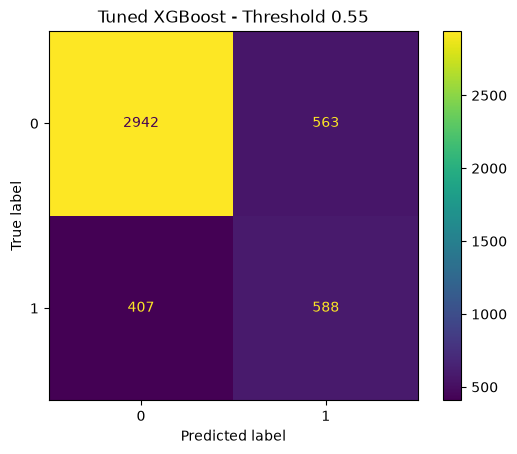

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_final_pred
)

plt.title(
    f"Tuned XGBoost - Threshold {best_threshold:.2f}"
)

plt.show()

In [20]:
tn, fp, fn, tp = confusion_matrix(
    y_val,
    y_val_final_pred
).ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 2942
False Positive: 563
False Negative: 407
True Positive : 588


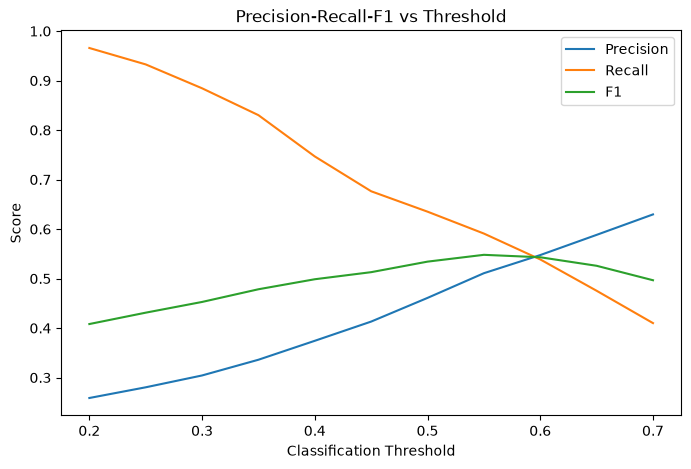

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Precision-Recall-F1 vs Threshold"
)

plt.legend()
plt.show()

## 4. Save Tuning Results

The tuning results and selected classification threshold are saved for use
in the final model evaluation.

In [22]:
cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results.to_csv(
    PROJECT_ROOT
    / "reports"
    / "xgb_tuning_results.csv",
    index=False
)

In [23]:
threshold_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "threshold_results.csv",
    index=False
)

In [24]:
final_selection = pd.DataFrame([
    {
        "Best_CV_PR_AUC":
            random_search.best_score_,

        "Selected_Threshold":
            best_threshold,

        "Validation_Accuracy":
            accuracy_score(
                y_val,
                y_val_final_pred
            ),

        "Validation_Precision":
            precision_score(
                y_val,
                y_val_final_pred
            ),

        "Validation_Recall":
            recall_score(
                y_val,
                y_val_final_pred
            ),

        "Validation_F1":
            f1_score(
                y_val,
                y_val_final_pred
            ),

        "Validation_ROC_AUC":
            roc_auc_score(
                y_val,
                y_val_prob
            ),

        "Validation_PR_AUC":
            average_precision_score(
                y_val,
                y_val_prob
            )
    }
])

final_selection

,Best_CV_PR_AUC,Selected_Threshold,Validation_Accuracy,Validation_Precision,Validation_Recall,Validation_F1,Validation_ROC_AUC,Validation_PR_AUC
0,0.562594,0.55,0.784444,0.51086,0.590955,0.547996,0.782644,0.561042


In [25]:
final_selection.to_csv(
    PROJECT_ROOT
    / "reports"
    / "final_model_selection.csv",
    index=False
)

In [28]:
import json
BEST_PARAMS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "best_xgb_params.json"
)

with open(BEST_PARAMS_PATH, "w") as f:
    json.dump(
        random_search.best_params_,
        f,
        indent=4
    )

print(
    "Saved best parameters to:",
    BEST_PARAMS_PATH
)

Saved best parameters to: d:\1-PERSONAL\HOC-TAP\DS\credit-risk-default-prediction\reports\best_xgb_params.json


In [29]:
with open(BEST_PARAMS_PATH, "r") as f:
    saved_params = json.load(f)

saved_params

{'classifier__subsample': 0.8,
 'classifier__n_estimators': 200,
 'classifier__max_depth': 4,
 'classifier__learning_rate': 0.03,
 'classifier__colsample_bytree': 1.0}